<a href="https://colab.research.google.com/github/annaluizacarvalhaes-star/Checkpoint5-SERS/blob/main/Checkpoint2_SERS_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Separação entre Treino e Teste
from sklearn.model_selection import train_test_split

# 3. Criação do Modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# 4. Cálculo das Métricas de Avaliação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [30]:
df = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/refs/heads/main/Data_for_UCI_named.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas:**  
**Quantidade de colunas:**  
**Existem valores ausentes?**  
**Observações importantes sobre o dataset:**  

In [31]:
print(f"O csv possui a quantidade de linhas e colunas igual a respectivamente: {df.shape}")

O csv possui a quantidade de linhas e colunas igual a respectivamente: (10000, 14)


In [32]:
print(f" Sim, existem valores ausentes. \n{df.isnull().sum()}")

 Sim, existem valores ausentes. 
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [33]:
# Crie a variável y usando a coluna stab
y = df['stab']
y.head()


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

In [34]:
matriz_corr = df.corr(numeric_only=True)
matriz_corr.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494,0.275761
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764,0.290975
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497,0.280700
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491,0.278576
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451,0.010278


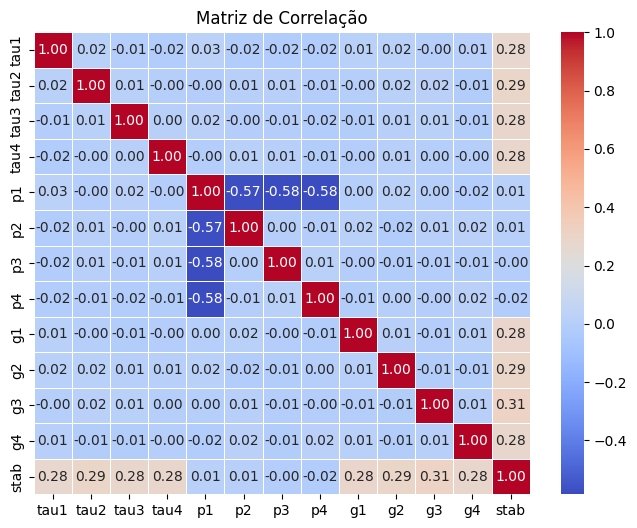

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.show()

In [36]:
corr_stab = matriz_corr["stab"]
corr_stab = corr_stab.drop("stab")
top_5_absoluto = corr_stab.abs().nlargest(5)
print(f"As cinco variáveis com maior correlação absoluta com stab são:\n{top_5_absoluto}")

As cinco variáveis com maior correlação absoluta com stab são:
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
Name: stab, dtype: float64


## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

As cinco variáveis com maior correlação (absoluta) com 'stab' são:
Variável: g3, Correlação: 0.3082
Variável: g2, Correlação: 0.2936
Variável: tau2, Correlação: 0.2910
Variável: g1, Correlação: 0.2828
Variável: tau3, Correlação: 0.2807


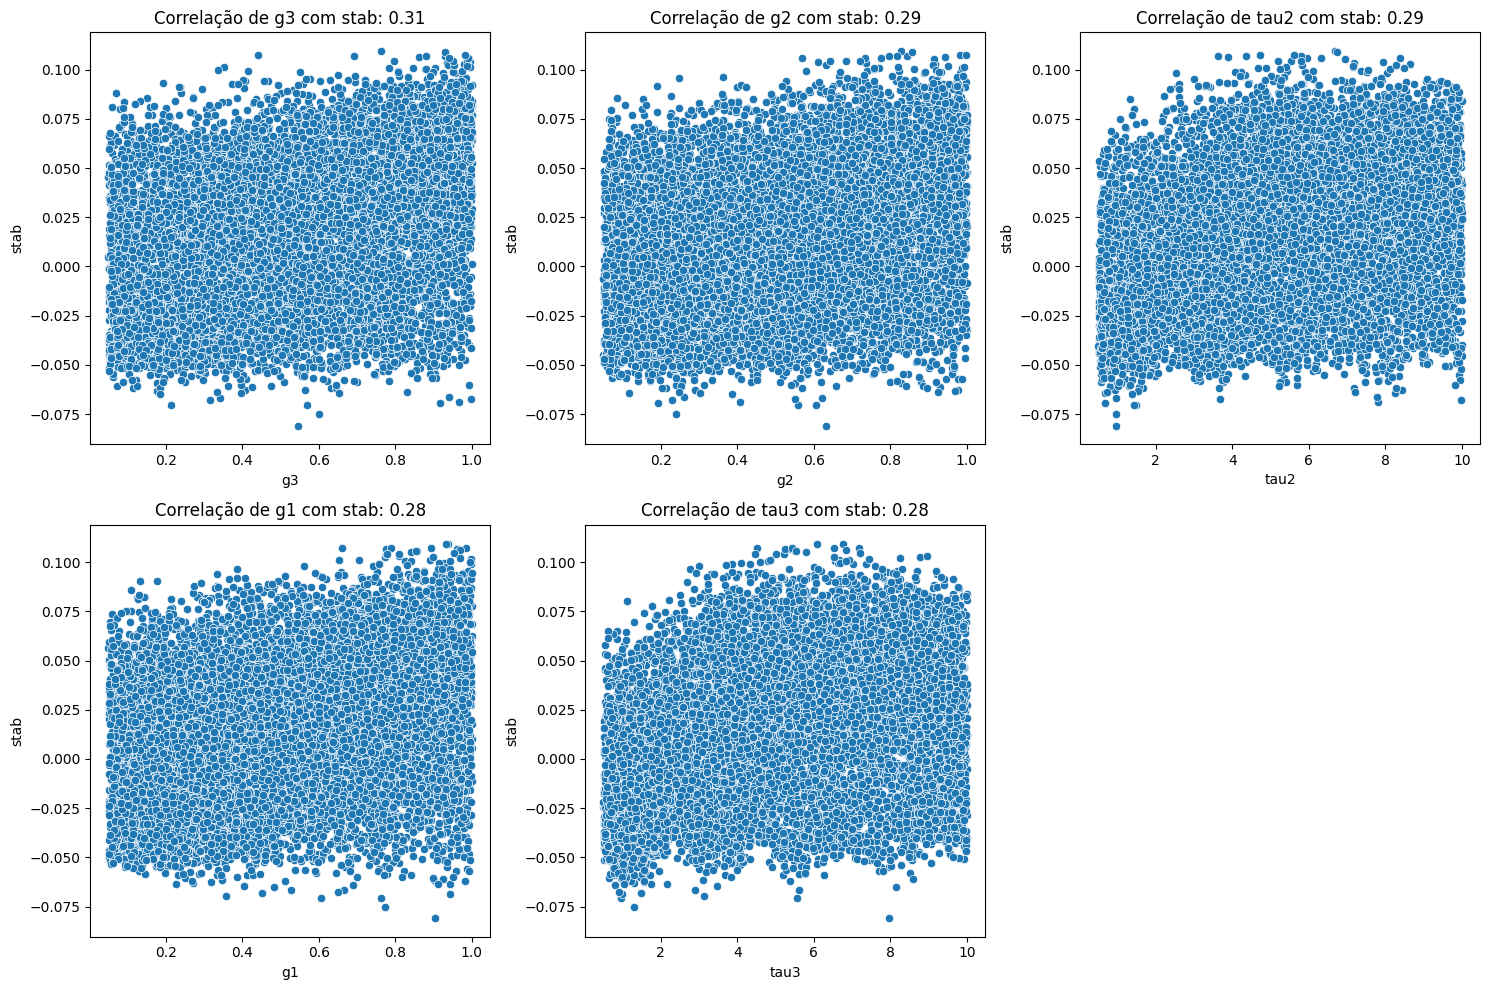

In [37]:
# Calcule a correlação das variáveis numéricas com 'stab'
correlacoes_com_stab = matriz_corr['stab'].drop('stab')

# Use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação
cinco_maiores_correlacoes_abs = correlacoes_com_stab.abs().nlargest(5)

# Obtenha os nomes das variáveis e seus valores de correlação originais
cinco_variaveis = cinco_maiores_correlacoes_abs.index.tolist()
correlacoes_originais = correlacoes_com_stab[cinco_variaveis]

print("As cinco variáveis com maior correlação (absoluta) com 'stab' são:")
for var, corr_val in correlacoes_originais.items():
    print(f"Variável: {var}, Correlação: {corr_val:.4f}")

# Crie cinco gráficos de dispersão
plt.figure(figsize=(15, 10))
for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1) # Ajuste o layout conforme necessário
    sns.scatterplot(data=df, x=var, y='stab')
    plt.title(f'Correlação de {var} com stab: {correlacoes_originais[var]:.2f}')
    plt.xlabel(var)
    plt.ylabel('stab')
plt.tight_layout()
plt.show()


### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0.308235 |
| 2 | g2 | 0.293601 |
| 3 | tau2 |  0.290975 |
| 4 | g1 | 0.282774 |
| 5 | tau3 | 0.280700 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta:  A variável g3 apresentou maior correlação com stab

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta:  Indicam como cada grupo de variáveis afeta diretamente o índice de estabilidade (stab) do sistema.

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [38]:
# Crie X com as cinco variáveis selecionadas
X = df[cinco_variaveis]
X.head()

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


In [39]:
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [40]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
X.shape

(10000, 5)

In [42]:
X_treino.shape[0] # 80% do total

8000

In [43]:
X_teste.shape[0] # 20% do total

2000

In [44]:
y.shape

(10000,)

In [45]:
y_treino.shape[0]

8000

In [46]:
y_teste.shape[0]

2000

## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [47]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)
# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)
y_previsao_1[:20]

array([ 0.0478946 ,  0.03781055, -0.00143381, -0.03422274,  0.01228364,
        0.02246186,  0.03723228,  0.06337778,  0.03332667, -0.00695869,
        0.04601661,  0.00369662, -0.0030212 ,  0.0305213 ,  0.02425743,
        0.01315086,  0.0072466 ,  0.04296824,  0.02383749,  0.02880063])

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [48]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"R² do Modelo 1: {r2_modelo_1:.2f}")
print(f"MAE do Modelo 1: {mae_modelo_1:.2f}")
print(f"MSE do Modelo 1: {mse_modelo_1:.2f}")

R² do Modelo 1: 0.40
MAE do Modelo 1: 0.02
MSE do Modelo 1: 0.00


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [49]:
# Selecione todas as colunas iniciadas por tau ou g
X_tau_g = df.filter(regex='^(tau|g)')
X_tau_g.head()

,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [50]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
# Confirme se y_teste e y2_teste possuem os mesmos índices
y_teste.equals(y2_teste)

True

## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [51]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)
# Calcule e apresente as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

In [52]:
print(f"R² do Modelo 2: {r2_modelo_2:.2f}")
print(f"MAE do Modelo 2: {mae_modelo_2:.2f}")
print(f"MSE do Modelo 2: {mse_modelo_2:.2f}")

R² do Modelo 2: 0.65
MAE do Modelo 2: 0.02
MSE do Modelo 2: 0.00


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [53]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['Cinco variáveis', 'Todas as variáveis tau e g'],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})
comparacao_modelos.head()


,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,Cinco variáveis,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis tau e g,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_2323/1570233212.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modelo", y="R²", data=comparacao_modelos, ax=axes[0], palette=cores)
/tmp/ipykernel_2323/1570233212.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modelo", y="MAE", data=comparacao_modelos, ax=axes[1], palette=cores)
/tmp/ipykernel_2323/1570233212.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modelo", y="MSE", data=comparacao_modelos, ax=axes[2], palette=cores)


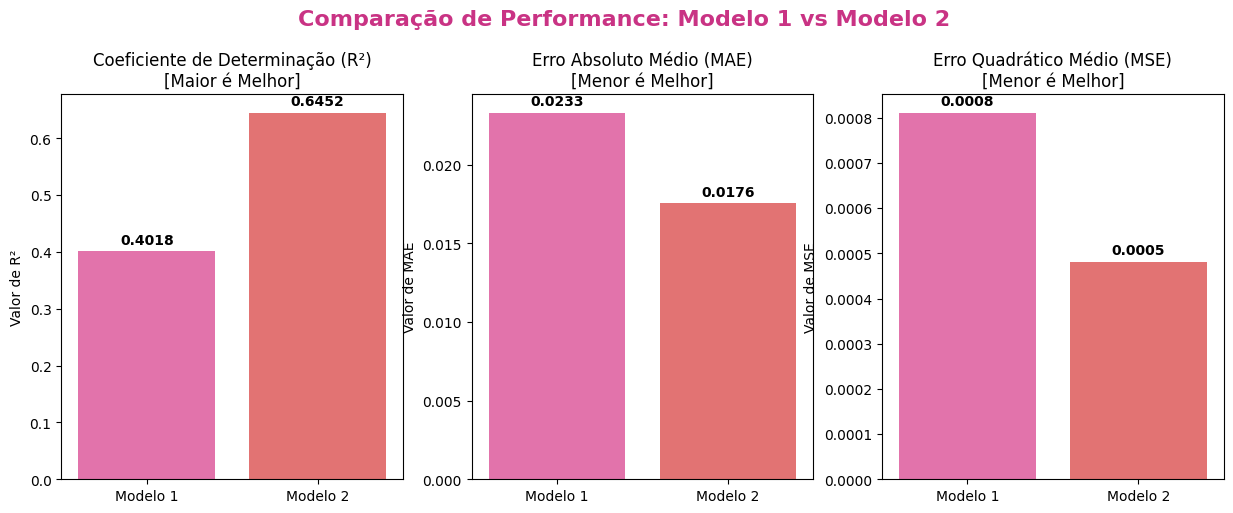

In [54]:
# Crie os gráficos comparativos das métricas
# comparacao_modelos = pd.DataFrame(df) # Esta linha estava sobrescrevendo o DataFrame correto

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Comparação de Performance: Modelo 1 vs Modelo 2",
    fontsize=16,
    fontweight="bold",
    y=1.05,
    color="#C93384"
)
cores = ["#f461ab", "#f46161"]

# Gráfico 1
sns.barplot(x="Modelo", y="R²", data=comparacao_modelos, ax=axes[0], palette=cores)
axes[0].set_title("Coeficiente de Determinação (R²)\n[Maior é Melhor]", fontsize=12)
axes[0].set_ylabel("Valor de R²")
axes[0].set_xlabel("")

for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

# Gráfico 2
sns.barplot(x="Modelo", y="MAE", data=comparacao_modelos, ax=axes[1], palette=cores)
axes[1].set_title("Erro Absoluto Médio (MAE)\n[Menor é Melhor]", fontsize=12)
axes[1].set_ylabel("Valor de MAE")
axes[1].set_xlabel("")

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )

# Gráfico 3
sns.barplot(x="Modelo", y="MSE", data=comparacao_modelos, ax=axes[2], palette=cores)
axes[2].set_title("Erro Quadrático Médio (MSE)\n[Menor é Melhor]", fontsize=12)
axes[2].set_ylabel("Valor de MSE")
axes[2].set_xlabel("")

for p in axes[2].patches:
    axes[2].annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight = 'bold',

    )

obs: os valores foram arredondados

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta:  O modelo 2. O primeiro modelo apresentou R² igual a aproximadamente 0.4018 e o segundo a 0.6452

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta:  O modelo 2. O primeiro modelo apresentou MAE igual a aproximadamente 0.0233 e o segundo a 0.0176


**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta:  O modelo 2. O primeiro modelo apresentou MSE igual a aproximadamente 0.0008 e o segundo a 0.0005


**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta:  Sim, pois o modelo 2 possui o maior R² e menor MAE e MSE (quanto menor, maior o desempenho).

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta:  O desempenho aumentou. O R² aumentou e o MSE e MAE diminuiram.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Modelo 2, possui maior precisão. R^2 é significativamente maior no Modelo 2 com aproximadamente 0,6452 em comparação ao Modelo 1 com aproximadamente 0,4018; o que indica que o segundo modelo é capaz de explicar uma proporção muito maior da variabilidade dos dados. MAE é menor no Modelo 2 (0,0176), equanto o modelo 1 (0,0233), mostrando que os erros absolutos das previsões são, em média, menores. Já o MSE é menor no Modelo 2 também, (0,0005) do que no Modelo 1 (0,0008), confirmando que o modelo 2 penaliza menos erros de grande magnitude e possui maior precisão geral.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.